In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tensorflow as tf

from tensorflow.keras import layers
from mpl_toolkits.mplot3d import Axes3D
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import KFold, GridSearchCV
from scipy.integrate import ode

plt.rcParams.update({'font.size': 12})

- Funkcije

In [2]:
def integratorLorenz63(
        X0, Y0, Z0, integration_time,
        sigma=10., b = 8./3, r=28.
        ):
    """
    Integracija Lorenzovega '63 modela
    Args:
    - X0, Y0, Z0 = X(t=0), Y(t=0), Z(t=0) -> začetni pogoji
    - integration_time -> 1 enota = 100 korakov pri dt=0.01
    - sigma, b, r -> konstante sistema enačb
    """

    # Funkcija za integracijo: parcialno X/parcialno tau
    def f(t, X):
        # Desna stran Lorenz '63 sistema
        return [sigma*(X[1]-X[0]),
                X[0]*(r-X[2])-X[1],
                X[0]*X[1]-b*X[2]]
    
    def jac(t, X):
    # Jakobian sistema
        return [[-sigma, sigma, 0],
                [r-X[2], X*(r-X[2])-1, -X[0]],
                [X[1], X[0], -b]]
    
    # Integrator Runge-Kutta reda (4)5
    Integrator = ode(f, jac).set_integrator('dopri5')

    # Začetni pogoj za integracijo
    X0 = [X0, Y0, Z0] # Pozor - tu redefiniramo X0
    t0 = 0
    Integrator.set_initial_value(X0, t0)

    # Časovni korak integracije
    dt = 0.01

    # Tabeli za shranjevanje rezultatov integracije
    t = [0.]
    X = [X0]

    # Integracija
    while Integrator.successful() and Integrator.t+dt < integration_time:
        t.append(float(Integrator.t+dt))
        X.append(list(Integrator.integrate(Integrator.t+dt)))
        
    return np.array(t), np.array(X)


# Sekvenciranje multivariatnega zaporedja
def split_into_sequences(
        multivariate_sequence, input_seq_len,
        start_every_num_steps=8):
    """
    multivariate_sequence: shape (T, d); T=# čas. korakov, d=# dimenzij
    input_seq_len: dolžina vhodnega zaporedja
    start_every_num_steps: koliko časovnih korakov izpustimo,
    preden shranimo novo sekvenco
    """

    X, y = list(), list()
    
    # Zanka skozi vse časovne korake
    for i in range(0, len(multivariate_sequence), start_every_num_steps):

        # Zadnji indeks sekvence
        end_ix = i + input_seq_len

        # Preveri če je zadnji indeks izven multivariate_sequence
        if end_ix > len(multivariate_sequence)-1:
            break

        # seq_x je sestavljena iz input_seq_len korakov
        seq_x = multivariate_sequence[i:end_ix, :]
        # seq_y je samo 1 element za napoved
        seq_y = multivariate_sequence[end_ix, :]

        X.append(seq_x)
        y.append(seq_y)

    return np.array(X), np.array(y)


# Custom layer for Luong Attention
@tf.keras.utils.register_keras_serializable()
class LuongAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(LuongAttention, self).__init__(**kwargs)
    
    def call(self, decoder_hidden, encoder_outputs):
        # Izračun skalarnega produkta med skritim stanjem dekodirnika
        # in skritimi stanji kodirnika. V ta namen za vsak primer v batchu
        # množimo matriko z vrsticami skritih stanj kodirnika s
        # transponirano matriko skritih stanj dekodirnika (tf.matmul).
        score = tf.matmul(encoder_outputs, decoder_hidden, transpose_b=True)
        # shape = (batch_size, time_steps_encoder, time_steps_decoder=1)

        # Izračunamo uteži pozornosti - softmax po osi kodirnih skritih stanj
        attention_weights = tf.nn.softmax(score, axis=1)
        # shape = (batch_size, time_steps_encoder, time_steps_decoder=1)

        # Vektor konteksta je s pozornostjo utežena linearna kombinacija
        # izhodov kodirnika.
        context_vector = tf.reduce_sum(
                    attention_weights * encoder_outputs, axis=1)
        # shape = (batch_size, hidden_size)

        return context_vector, attention_weights
    

def create_SimpleRNN_model():
    """
    Creates a SimpleRNN model
    """
    model = tf.keras.models.Sequential()
    model.add(SimpleRNN(
        units=16, # dimenzija skritega stanja
        return_sequences=False,
        input_shape=(None,3))
        )
    # ekvivalent za LSTM: model.add(LSTM(...))
    # Zadnje skrito stanje še preslikamo v izhodni vektor y
    model.add(Dense(3))
    # Nastavitve za učenje modela
    model.compile(loss='mean_squared_error', optimizer='Adam')
    return model


def create_Luong_attention_model():
    """
    Creates a model with Luong attention vector.
    """
    
    """   KODIRNIK   """
    # Vhodni tenzor za kodirnik
    encoder_inputs = tf.keras.Input(shape=(None, 3))
    # Kodirni sloj
    encoder_lstm = layers.LSTM(
        units=16, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='encoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Pošlji vhodni tenzor kodirnika skozi kodirnik
    encoder_hidden_states, state_h, state_c = encoder_lstm(encoder_inputs)
    # encoder_hidden_states shape: # (batch_size, encoder_time_steps, hidden_size)
    
    
    """   DEKODIRNIK   """
    # Vhodni tenzor za dekodirnik
    decoder_inputs = tf.keras.Input(shape=(None, 3))
    # Dekodirni sloj
    decoder_lstm = layers.LSTM(
        units=16, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name='decoder' # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Nastavi začetno skrito in celično stanje dekodirnika
    # in pošlji vhodni tenzor dekodirnika skozi dekodirnik
    decoder_hidden_states, _, _ = decoder_lstm(
        decoder_inputs, initial_state=[state_h, state_c])
    # decoder_hidden_states shape: # (batch_size, decoder_time_steps, hidden_size)
    
    
    """   Luongov mehanizem pozornosti (Luong Attention)   """
    attention_layer = LuongAttention()
    context_vector, attention_weights = attention_layer(
        decoder_hidden_states, encoder_hidden_states)
    
    # Konkateniramo vektorje konteksta s skritimi stanji dekoderja
    # combined_context = layers.Concatenate(axis=-1)(
    #     [decoder_hidden_states, tf.expand_dims(context_vector, 1)])
    
    context_vector_exp = layers.Reshape((1, 16))(context_vector)
    combined_context = layers.Concatenate(axis=-1)([decoder_hidden_states, context_vector_exp])

    # Konkatenirane vektorje preslikamo v nova skrita stanja, tako da
    # jih pošljemo skozi gosto povezano NN. V ta namen uporabimo sloj
    # TimeDistributed, ki aplicira uteži na vse izhode.
    new_decoder_hidden_states = layers.TimeDistributed(
        layers.Dense(units=16, activation="tanh"))(combined_context)
    # Nova skrita stanja z gosto povezano NN preslikamo v izhode.

    outputs = layers.TimeDistributed(
        layers.Dense(3))(new_decoder_hidden_states)
    # Ustvarimo model (funkcijo oz. računski graf), tako da definiramo

    # vhodna in izhodna polja.
    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs = outputs)

    # Konfiguriramo nastavitve za učenje
    model.compile(loss='mean_squared_error', optimizer='Adam')

    return model


def run_KFold(model, X, Y, n_splits, save_path):
    """
    Runs KFold for a chosen model
    """
    os.makedirs(save_path, exist_ok=True)

    # Callbacks 
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=8,
        min_lr=1e-4
    )

    kf = KFold(n_splits)
    histories = []
    scores_MSE = []
    fold = 1

    for train_idx, test_idx in kf.split(X, Y):

        print(f"Training fold {fold}...")
        
        if model == "SimpleRNN":
            model = create_SimpleRNN_model()
        else:
            model = create_Luong_attention_model()

        model_path = os.path.join(save_path, f"model_fold_{fold}.keras")

        # Callback
        checkpoint = tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,   # shrani cel model (struktura + uteži)
            verbose=0
        )

        history = model.fit(
            X[train_idx], Y[train_idx],
            epochs=200,
            batch_size=100,
            verbose=0,
            validation_split=0.1,
            shuffle=True,
            callbacks=[early_stop, checkpoint, reduce_lr]
        )

        histories.append(history)

        best_model = tf.keras.models.load_model(model_path)

        mse = best_model.evaluate(X[test_idx], Y[test_idx], verbose=0)

        scores_MSE.append(mse)

        print(f" Fold {fold} → MSE = {mse:.4f}")
        fold += 1

    # -----------------------------
    # Rezultati
    # -----------------------------
    print("\n============================")
    print("FINAL RESULTS OVER ALL FOLDS")
    print("============================")

    print(f"Average MSE: {np.mean(scores_MSE):.4f} ± {np.std(scores_MSE):.4f}")

    return scores_MSE, histories


def napoved(N, model, input_seq_len, X_ics_norm, scaler, Luong_attention=False):
    """
    Funkcija za izračun modelskih napovedi
    args:
    - N: število začetnih pogojev
    - model: rekurentni model brez Luongove pozornosti
    model = tf.keras.models.load_model(path_model)
    - input_seq_len: dolžina vhodne sekvence v model
    - Luong_attention (bool): True, če imamo model z Luongovo pozornostjo
    """
    
    # Priprava vhodnega tenzorja
    X_start = np.expand_dims(X_ics_norm[:,-input_seq_len], axis=1)
    for j in range(input_seq_len-1, 0, -1):
        X_start = np.append(
        X_start, np.expand_dims(X_ics_norm[:,-j], axis=1),
        axis=1
        )
    
    # Tabela za zapisovanje napovedi - prva vrednost je začetni pogoj
    pred = X_start[:,-1:]
    
    if Luong_attention:
        start_token = X_start[:,-1:]
    
    # Izvedba napovedi za 10 enot časa
    T = [0.]

    for t in range(10*100):
        if Luong_attention == False:
            # Brez Luongove pozornosti:
            next_step = model.predict(X_start)
            next_step = np.expand_dims(next_step, axis=1)
            pred = np.append(pred, next_step, axis=1)
            X_start = np.concatenate((X_start[:,1:], next_step), axis=1)
        else:
            next_step = model.predict([X_start, start_token])
            pred = np.append(pred, next_step, axis=1)
            X_start = np.concatenate((X_start[:,1:], next_step), axis=1)
            start_token = X_start[:, -1:]

        # Napovedi reskaliramo v osnovno velikost
        predictions = []

        for i in range(N):
            predictions.append(scaler.inverse_transform(pred[i,:,:]))
        T.append((t+1)*0.01)

    return np.array(T), np.array(predictions)

## Priprava podatkov

In [3]:
""" Učni ter validacijski podatki """

# Za ponovljivost določimo seme
np.random.seed(42)

#Začetni pogoj za učno trajektorijo
X0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
Y0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
Z0_train = float(np.random.uniform(low=-50., high = 50., size = 1))

# Čas integracije
t_train = 8030. # Prvih 30 enot časa bomo odstranili

# Numerična integracija
t_train, data_train = integratorLorenz63(
    X0_train, Y0_train, Z0_train,
    t_train)

# Odrežemo prvih 30 enot časa - da ohranimo le točke na atraktorju
relaksacijski_indeks = 3000
data_train = np.array(data_train)[relaksacijski_indeks:, :]

# Podatke razdelimo na učno in validacijsko množico
# 90 % za učenje, 10 % za validacijo
split_idx = int(0.1 * len(data_train))

X_val = data_train[:split_idx]
X_train = data_train[split_idx:]

# Uporabimo standardizacijo (opcija je tudi MinMaxScaler)
scaler = StandardScaler()
# Povprečje in std izračunamo na učni množici (ne na validacijski)!
scaler.fit(X_train)

# Izpiši povprečno vrednost in standardno deviacijo
print("Povprečje:", scaler.mean_)
print("Standardna deviacija:", scaler.scale_)

# Normiramo podatke
X_train_norm = scaler.transform(X_train)
X_val_norm = scaler.transform(X_val)

input_seq_len = 5
# Učni podatki
X1_train, Y1_train = split_into_sequences(X_train_norm, input_seq_len)
# Validacijski podatki
X1_val, Y1_val = split_into_sequences(X_val_norm, input_seq_len)

C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\2448391325.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\2448391325.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y0_train = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\2448391325.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

Povprečje: [-0.03917021 -0.0391126  23.55120557]
Standardna deviacija: [7.92470512 9.01091533 8.62086367]


In [4]:
""" Testni podatki """

# Število začetnih pogojev
N = 200

# Seme za ponovljivost eksperimenta
np.random.seed(10043)

# Začetni pogoji za učno trajektorijo
X0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
Y0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
Z0_test = float(np.random.uniform(low=-50., high = 50., size = 1))

# Čas integracije
t_test = 30.0 + N
# Numerična integracija
t_test, X_test = integratorLorenz63(X0_test, Y0_test, Z0_test, t_test)

# Relaksacija: odrežemo prvih 30.0 enot časa
relaksacijski_indeks = 3001 # 1, ker je vključen tudi začetni pogoj
X_test = X_test[relaksacijski_indeks:, :]

# Pripravimo začetne pogoje (ics=initial conditions)
X_ics = X_test[:N*100].reshape(N, 100, 3)
# Normiramo začetne pogoje
X_ics_norm = scaler.transform(X_test)[:N*100].reshape(N, 100, 3)
# X_ics(_norm).shape: (N, 100, 3)

C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\960818173.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\960818173.py:11: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Y0_test = float(np.random.uniform(low=-50., high = 50., size = 1))
C:\Users\tadej\AppData\Local\Temp\ipykernel_8872\960818173.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
 

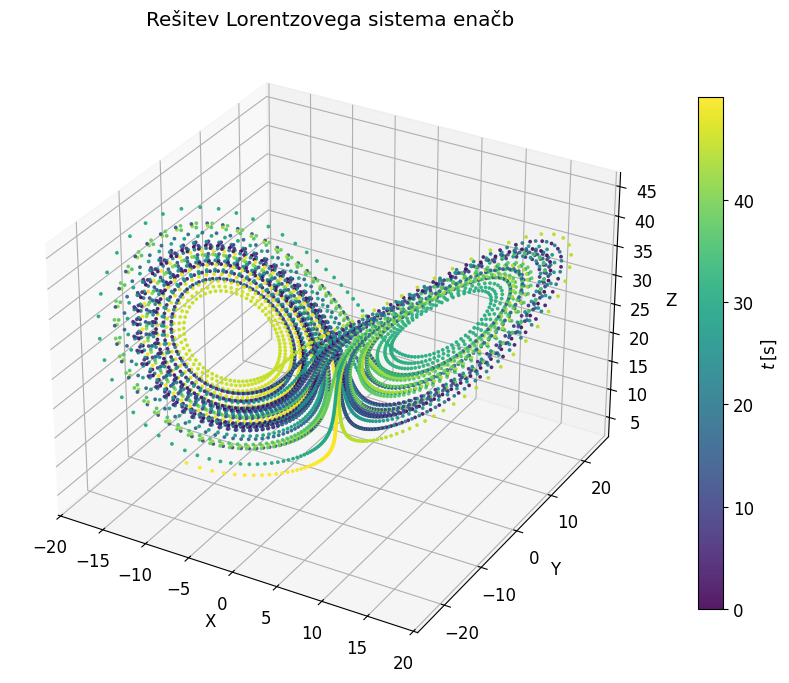

In [20]:
X_plot = data_train[:, 0][:5000]
Y_plot = data_train[:, 1][:5000]
Z_plot = data_train[:, 2][:5000]
t_plot = t_test[:5000]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(
    X_plot, Y_plot, Z_plot,
    c=t_plot,
    cmap='viridis',
    s=3,
    alpha=0.9
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Naslov
ax.set_title("Rešitev Lorentzovega sistema enačb")

# Barvna lestvica
cbar = plt.colorbar(sc, shrink=0.8)
cbar.set_label(r"$t \, [\text{s}]$")

plt.tight_layout()
plt.show()

## SimpleRNN mreža

In [45]:
""" Trening SimpleRNN mreže """

modelRNN = create_SimpleRNN_model()

# Callbacks 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=8,
    min_lr=1e-4
)

fitRNN = modelRNN.fit(
    x=X1_train,
    y=Y1_train,
    batch_size=300,
    epochs=1000,
    validation_data=(X1_val, Y1_val),
    callbacks=[reduce_lr, early_stop],
    shuffle=True)

modelRNN.save('modelRNN.keras')

Epoch 1/1000


c:\Users\tadej\Desktop\STUDIJ\mag-2.letnik\PSUF\PSUF-venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0748 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0046 - val_loss: 0.0026 - learning_rate: 0.0010
Epoch 3/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019 - val_loss: 0.0014 - learning_rate: 0.0010
Epoch 4/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0011 - val_loss: 9.1385e-04 - learning_rate: 0.0010
Epoch 5/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.1598e-04 - val_loss: 6.0958e-04 - learning_rate: 0.0010
Epoch 6/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.8607e-04 - val_loss: 4.2417e-04 - learning_rate: 0.0010
Epoch 7/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.4059e-04 - val_loss: 3.0265e-04 - learning_rate: 0.0010
Epoch 8/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.4518e-04 - val_loss: 2.2348e-04 - learning_rate: 0.0010
Epoch 9/1000
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.7989e-04 - val_lo

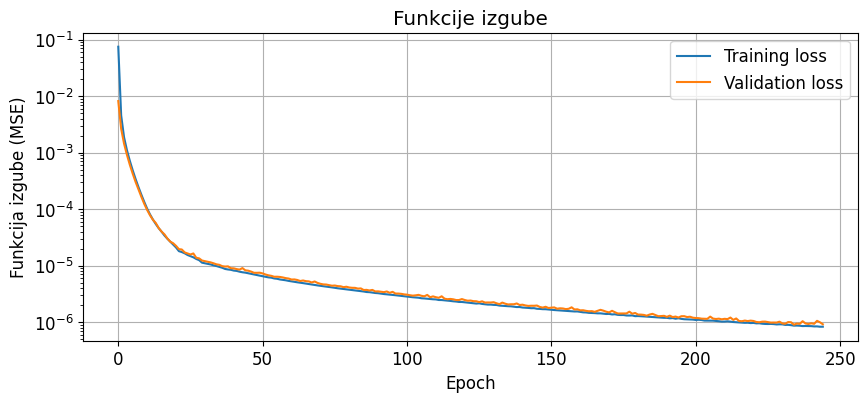

In [46]:
""" Loss function """
history = fitRNN.history

plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Training loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Funkcija izgube (MSE)')
plt.title('Funkcije izgube')
plt.legend()
plt.grid(True)
plt.show()

In [67]:
""" Predikcije """

model = tf.keras.models.load_model("modelRNN.keras")

ts, pred = napoved(N, model, input_seq_len, X_ics_norm, scaler) # Napovedi

X_true = np.zeros_like(pred) # Realne vrednosti
for i in range(N):
    _, X_true[i] = integratorLorenz63(*tuple(pred[i, 0, :]), ts[-1])

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


KeyboardInterrupt: 

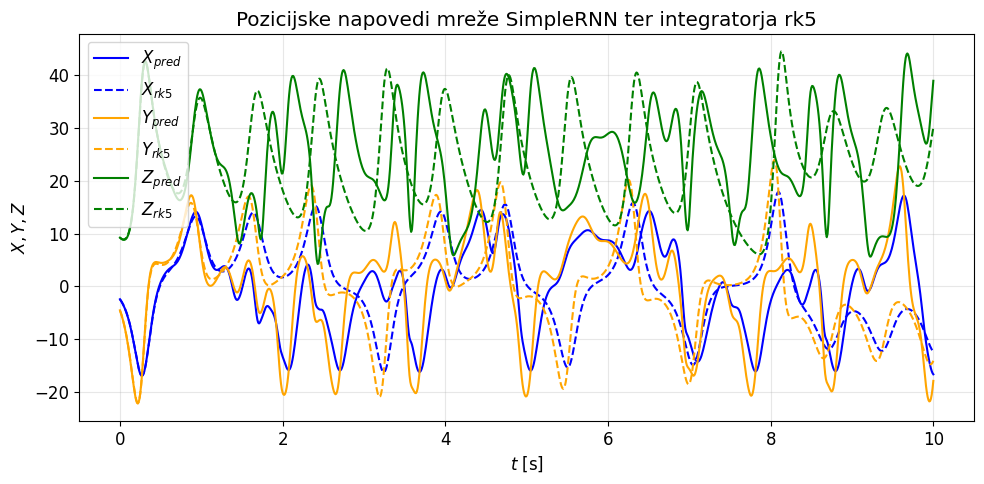

In [7]:
""" Plottane predikcije in realne vrednosti """

plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže SimpleRNN ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$X, Y, Z$')
plt.grid(alpha=0.3)
plt.plot(ts, pred[11, :, 0], c='blue', label=r'$X_{pred}$')
plt.plot(ts, X_true[11, :, 0], c='blue', ls='--', label=r'$X_{rk5}$')
plt.plot(ts, pred[11, :, 1], c='orange', label=r'$Y_{pred}$')
plt.plot(ts, X_true[11, :, 1], c='orange', ls='--', label=r'$Y_{rk5}$')
plt.plot(ts, pred[11, :, 2], c='green', label=r'$Z_{pred}$')
plt.plot(ts, X_true[11, :, 2], c='green', ls='--', label=r'$Z_{rk5}$')
plt.legend()
plt.tight_layout()
plt.show()

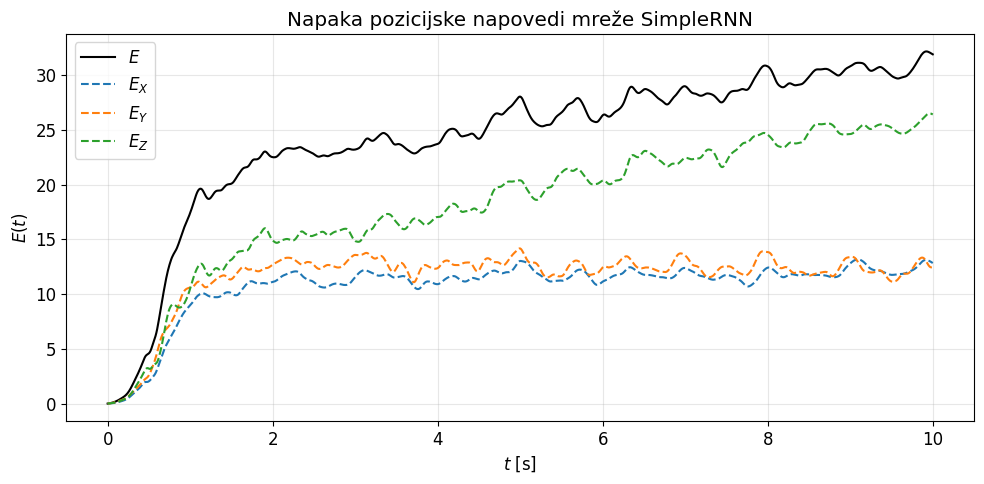

In [8]:
""" Napaka predikcije """

errRNN = np.sqrt(np.sum((pred - X_true)**2, axis=(0, 2)) / N)
errRNN_XYZ = np.sqrt(np.sum((pred - X_true)**2, axis=0) / N)

plt.figure(figsize=(10, 5))
plt.title('Napaka pozicijske napovedi mreže SimpleRNN')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$E (t)$')
plt.grid(alpha=0.3)
plt.plot(ts, errRNN, c='black', label=r'$E$')
plt.plot(ts, errRNN_XYZ[:, 0], ls='--', label=r'$E_X$')
plt.plot(ts, errRNN_XYZ[:, 1], ls='--', label=r'$E_Y$')
plt.plot(ts, errRNN_XYZ[:, 2], ls='--', label=r'$E_Z$')
plt.legend()
plt.tight_layout()
plt.show()

## Luongova pozornost

In [64]:
""" Trening Luong attention mreže """

modelLuong = create_Luong_attention_model()

# Callbacks 
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.4,
    patience=8,
    min_lr=1e-4
)

fitLuong = modelLuong.fit(
    x=[X1_train, X1_train[:,-1:]],
    y=np.expand_dims(Y1_train, axis=1),
    batch_size=300,
    epochs=500,
    validation_data=([X1_val, X1_val[:,-1:]], np.expand_dims(Y1_val, axis=1)),
    callbacks=[reduce_lr, early_stop],
    shuffle=True)

modelLuong.save('modelLuong.keras')

Epoch 1/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.1102 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0027 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.1379e-04 - val_loss: 5.7160e-04 - learning_rate: 0.0010
Epoch 4/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.0982e-04 - val_loss: 3.2969e-04 - learning_rate: 0.0010
Epoch 5/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.4558e-04 - val_loss: 2.0805e-04 - learning_rate: 0.0010
Epoch 6/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1.5550e-04 - val_loss: 1.3343e-04 - learning_rate: 0.0010
Epoch 7/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 9.9759e-05 - val_loss: 8.6570e-05 - learning_rate: 0.0010
Epoch 8/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.4172e-05 - val_loss: 5.7746e-05 - learning_rate: 0.0010
Epoch 9/500
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.2

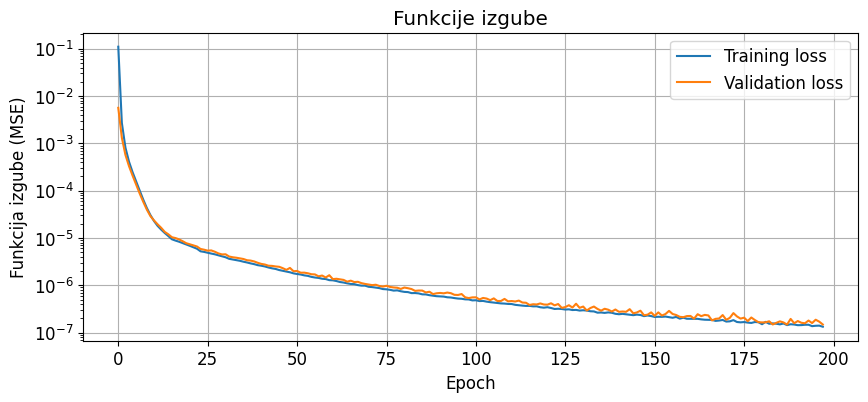

In [65]:
""" Loss function """

# History
history = fitLuong.history

plt.figure(figsize=(10, 4))
plt.plot(history['loss'], label='Training loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Funkcija izgube (MSE)')
plt.title('Funkcije izgube')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
""" Predikcije """

model = tf.keras.models.load_model(
    "modelLuong.keras",
    custom_objects={"LuongAttention": LuongAttention},
    safe_mode=False
)

ts, pred = napoved(N, model, input_seq_len, X_ics_norm, scaler, Luong_attention=True)

X_true = np.zeros_like(pred)
for i in range(N):
    _, X_true[i] = integratorLorenz63(*tuple(pred[i, 0, :]), ts[-1])


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━

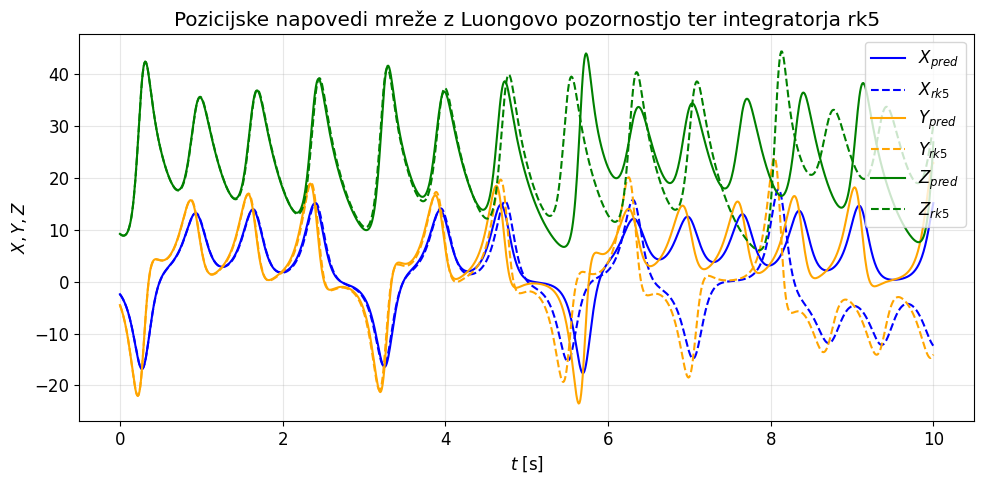

In [23]:
""" Plottane predikcije ter realne vrednosti """

plt.figure(figsize=(10, 5))
plt.title('Pozicijske napovedi mreže z Luongovo pozornostjo ter integratorja rk5')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$X, Y, Z$')
plt.grid(alpha=0.3)
plt.plot(ts, pred[11, :, 0], c='blue', label=r'$X_{pred}$')
plt.plot(ts, X_true[11, :, 0], c='blue', ls='--', label=r'$X_{rk5}$')
plt.plot(ts, pred[11, :, 1], c='orange', label=r'$Y_{pred}$')
plt.plot(ts, X_true[11, :, 1], c='orange', ls='--', label=r'$Y_{rk5}$')
plt.plot(ts, pred[11, :, 2], c='green', label=r'$Z_{pred}$')
plt.plot(ts, X_true[11, :, 2], c='green', ls='--', label=r'$Z_{rk5}$')
plt.legend()
plt.tight_layout()
plt.show()

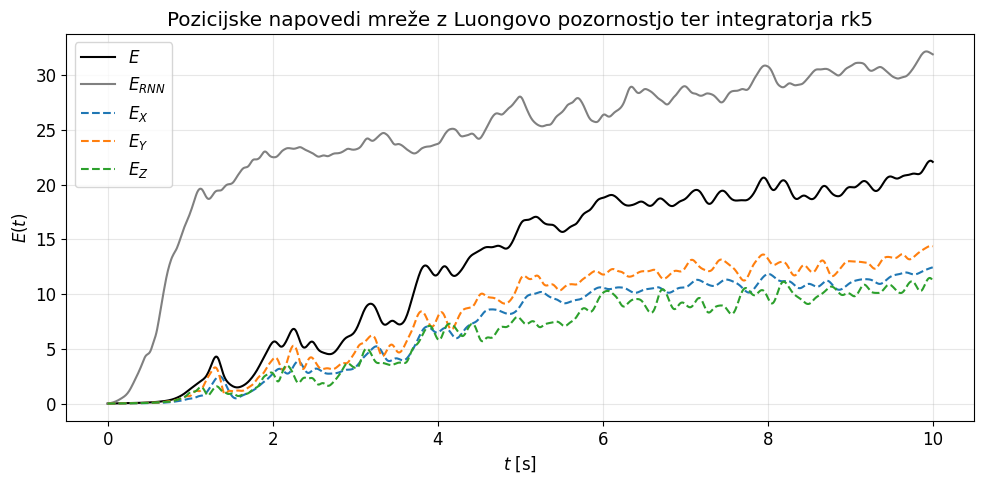

In [ ]:
""" Napake napovedi """

errLuong = np.sqrt(np.sum((pred - X_true)**2, axis=(0, 2)) / N)
errLuong_XYZ = np.sqrt(np.sum((pred - X_true)**2, axis=0) / N)

plt.figure(figsize=(10, 5))
plt.title('Napaka pozicijske napovedi mreže z Luongovo pozornostjo')
plt.xlabel(r'$t$ [s]')
plt.ylabel(r'$E (t)$')
plt.grid(alpha=0.3)
plt.plot(ts, errLuong, c='black', label=r'$E$')
plt.plot(ts, errRNN, c='Gray', label=r'$E_{RNN}$')
plt.plot(ts, errLuong_XYZ[:, 0], ls='--', label=r'$E_X$')
plt.plot(ts, errLuong_XYZ[:, 1], ls='--', label=r'$E_Y$')
plt.plot(ts, errLuong_XYZ[:, 2], ls='--', label=r'$E_Z$')
plt.legend()
plt.tight_layout()
plt.show()

### Iskanje optimalnih parametrov mreže z Luongovo pozornostjo

In [58]:
""" Funkcije za grid search """

def create_model(num_layers, hidden_units):
    """
    Creates a model with Luong attention vector.
    """
    
    """   KODIRNIK   """
    # Vhodni tenzor za kodirnik
    encoder_inputs = tf.keras.Input(shape=(None, 3))
    x = encoder_inputs
    
    # Sloji encoderja
    for i in range(num_layers-1):
        encoder_lstm = layers.LSTM(
            units=hidden_units,
            return_sequences=True,
            name=f"encoder_lstm_{i}"
            )
        x = encoder_lstm(x)
        
    # Zadnji sloj encoderja
    encoder_lstm = layers.LSTM(
        units=hidden_units, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name=f"encoder_lstm_{num_layers}" # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Pošlji vhodni tenzor kodirnika skozi kodirnik
    encoder_hidden_states, state_h, state_c = encoder_lstm(x)
    # encoder_hidden_states shape: # (batch_size, encoder_time_steps, hidden_size)
    
    
    """   DEKODIRNIK   """
    # Vhodni tenzor za dekodirnik
    decoder_inputs = tf.keras.Input(shape=(None, 3))
    x = decoder_inputs

    # Sloji decoderja
    for i in range(num_layers-1):
        decoder_lstm = layers.LSTM(
            units=hidden_units,
            return_sequences=True,
            name=f"decoder_lstm_{i}"
            )
        x = decoder_lstm(x)

    # Zadnji sloj decoderja
    decoder_lstm = layers.LSTM(
        units=hidden_units, # Število dimenzij skritega stanja
        return_sequences=True, # Vrni vsa skrita stanja
        return_state=True, # Vrni zadnje celično stanje
        name=f"decoder_lstm_{num_layers}" # Sloj poimenujemo za kasnejšo rabo
    )
    
    # Nastavi začetno skrito in celično stanje dekodirnika
    # in pošlji vhodni tenzor dekodirnika skozi dekodirnik
    decoder_hidden_states, _, _ = decoder_lstm(
        x, initial_state=[state_h, state_c])
    # decoder_hidden_states shape: # (batch_size, decoder_time_steps, hidden_size)
    
    
    """   Luongov mehanizem pozornosti (Luong Attention)   """
    attention_layer = LuongAttention()
    context_vector, attention_weights = attention_layer(
        decoder_hidden_states, encoder_hidden_states)
    
    context_vector_exp = layers.Reshape((1, hidden_units))(context_vector)
    combined_context = layers.Concatenate(axis=-1)([decoder_hidden_states, context_vector_exp])

    # Konkatenirane vektorje preslikamo v nova skrita stanja, tako da
    # jih pošljemo skozi gosto povezano NN. V ta namen uporabimo sloj
    # TimeDistributed, ki aplicira uteži na vse izhode.
    new_decoder_hidden_states = layers.TimeDistributed(
        layers.Dense(units=hidden_units, activation="tanh"))(combined_context)
    # Nova skrita stanja z gosto povezano NN preslikamo v izhode.

    outputs = layers.TimeDistributed(
        layers.Dense(3))(new_decoder_hidden_states)
    # Ustvarimo model (funkcijo oz. računski graf), tako da definiramo

    # vhodna in izhodna polja.
    model = tf.keras.Model(
        inputs=[encoder_inputs, decoder_inputs],
        outputs = outputs)

    # Konfiguriramo nastavitve za učenje
    model.compile(loss='mean_squared_error', optimizer='Adam')

    return model


def train_model(model, input_seq_len, model_name):
    # Učni podatki
    X1_train, Y1_train = split_into_sequences(X_train_norm, input_seq_len)
    # Validacijski podatki
    X1_val, Y1_val = split_into_sequences(X_val_norm, input_seq_len)

    # Callbacks 
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.4,
        patience=8,
        min_lr=1e-4
    )

    fit = model.fit(
        x=[X1_train, X1_train[:,-1:]],
        y=np.expand_dims(Y1_train, axis=1),
        batch_size=300,
        epochs=500,
        validation_data=([X1_val, X1_val[:,-1:]], np.expand_dims(Y1_val, axis=1)),
        callbacks=[reduce_lr, early_stop],
        shuffle=True)
    
    history = fit.history

    model.save(f'Luongmodels\\{model_name}_{input_seq_len}.keras')

    return history

In [59]:
""" Grid search """

num_layers = [1, 2]
hidden_units = [1, 8, 16, 32]
seq_length = [1, 2, 4, 8]

histories = {

}

for i in range(len(num_layers)):
    num_lay= num_layers[i]

    for j in range(len(hidden_units)):
        hidden_un = hidden_units[j]

        for k in range(len(seq_length)):
            seq_len = seq_length[k]

            model_name = f"model_{num_lay}_{hidden_un}_{seq_len}"
            print("-------------------------------------------------------------")
            print(f"# Training model {model_name} for sequance length {seq_len} #")
            print("-------------------------------------------------------------")

            model = create_model(num_lay, hidden_un)
            history = train_model(model, seq_len, model_name)

            histories[f"{model_name}"] = history

-------------------------------------------------------------
# Training model model_1_1_1 for sequance length 1 #
-------------------------------------------------------------
Epoch 1/500
 41/300 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0085 

KeyboardInterrupt: 

In [60]:
import pickle
# Naloži
with open("histories.pkl", "rb") as f:
    histories = pickle.load(f)

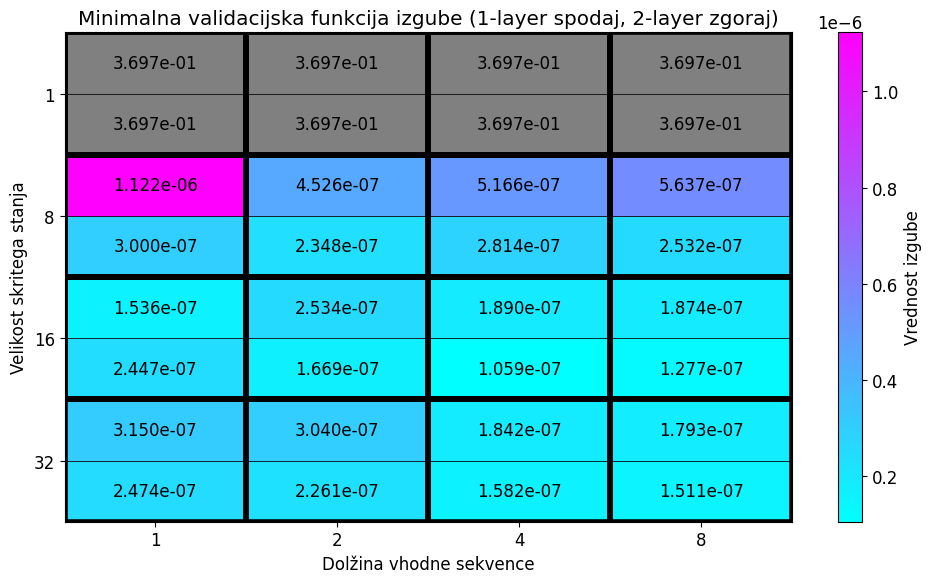

[[3.69710326e-01 3.69735658e-01 3.69703948e-01 3.69725674e-01]
 [1.12228338e-06 4.52630076e-07 5.16604700e-07 5.63736535e-07]
 [1.53598677e-07 2.53353164e-07 1.89039454e-07 1.87366965e-07]
 [3.14992548e-07 3.04042459e-07 1.84169267e-07 1.79343601e-07]]


In [61]:
""" Graf za grid search """

mins1 = []
mins2 = []

# Matrika za val_loss
val_loss_matrix_1layer = np.zeros((len(hidden_units), len(seq_length)))
val_loss_matrix_2layer = np.zeros((len(hidden_units), len(seq_length)))

# Napolnimo matriki
for i, hu in enumerate(hidden_units):
    for j, sl in enumerate(seq_length):
        key1 = f"model_1_{hu}_{sl}"
        key2 = f"model_2_{hu}_{sl}"
        
        val_loss_matrix_1layer[i, j] = min(histories[key1]['val_loss'])
        mins1.append(min(histories[key1]['val_loss']))
        val_loss_matrix_2layer[i, j] = min(histories[key2]['val_loss'])
        mins2.append(min(histories[key2]['val_loss']))

# Figure
fig, ax = plt.subplots(figsize=(10, 6))

vmin = min(val_loss_matrix_1layer[1:, :].min(), val_loss_matrix_2layer[1:, :].min())
vmax = max(val_loss_matrix_1layer[1:, :].max(), val_loss_matrix_2layer[1:, :].max())
cmap = plt.cm.cool

for i in range(len(hidden_units)):
    for j in range(len(seq_length)):

        # zgornja polovica (1 layer)
        v1 = val_loss_matrix_1layer[i, j]
        if i == 0:
            color1 = "gray"
        else:
            color1 = cmap((v1 - vmin) / (vmax - vmin))
        rect1 = patches.Rectangle((j, i + 0.5), 1, 0.5, facecolor=color1,
                                  edgecolor='k', linewidth=0.5)
        ax.add_patch(rect1)
        ax.text(j + 0.5, i + 0.75, f"{v1:.3e}", ha="center", va="center", color="black")

        # spodnja polovica (2 layers)
        v2 = val_loss_matrix_2layer[i, j]
        if i == 0:
            color2 = "gray"
        else:
            color2 = cmap((v2 - vmin) / (vmax - vmin))
        rect2 = patches.Rectangle((j, i), 1, 0.5, facecolor=color2,
                                  edgecolor='k', linewidth=0.5)
        ax.add_patch(rect2)
        ax.text(j + 0.5, i + 0.25, f"{v2:.3e}", ha="center", va="center", color="black")

        # horizontalna črta znotraj kvadratka (ločitev polovice)
        ax.plot([j, j + 1], [i + 1, i + 1], color='k', linewidth=4)
        ax.plot([j-1, j + 1], [i, i], color='k', linewidth=4)
        ax.plot([j + 1, j + 1], [i, i + 1], color='k', linewidth=4)
        ax.plot([j, j], [i - 1, i + 1 ], color='k', linewidth=4)

# osi
ax.set_xticks(np.arange(len(seq_length)) + 0.5)
ax.set_xticklabels(seq_length)

ax.set_yticks(np.arange(len(hidden_units)) + 0.5)
ax.set_yticklabels(hidden_units)

ax.set_xlabel("Dolžina vhodne sekvence")
ax.set_ylabel("Velikost skritega stanja")
ax.set_title("Minimalna validacijska funkcija izgube (1-layer spodaj, 2-layer zgoraj)")

# colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Vrednost izgube")

# Nastavimo meje, da je zadnja vrstica in stolpec vidna
ax.set_xlim(0, len(seq_length))
ax.set_ylim(0, len(hidden_units))

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(val_loss_matrix_2layer)

### Perturbacija uteži

In [40]:
""" Perturbacija """

base_model = tf.keras.models.load_model("Luongmodels/model_1_16_4_4.keras")
original_weights = base_model.get_weights()

perturbation_stds = [0.1, 0.01, 0.001, 0.0001]
num_perturbations = 25

results = {}   # Za shranjevanje MSE rezultatov
best_models = {}  # Za shranjevanje najboljšega modela pri vsakem STD

for std in perturbation_stds:
    print(f"\n=== STD = {std} ===")
    
    mse_list = []
    weight_list = []  # tukaj bomo shranili težo vsakega perturbiranega modela

    # 10 perturbacij za trenutni std
    for i in range(num_perturbations):
        # Perturbacija
        perturbed_weights = []
        for w in original_weights:
            noise = np.random.normal(0, std, size=w.shape)
            perturbed_weights.append(w + noise)

        # Uporabi pertubirane uteži
        base_model.set_weights(perturbed_weights)

        # Izračunaj MSE
        mse = base_model.evaluate(
            [X1_val, X1_val[:, -1:]],
            np.expand_dims(Y1_val, axis=1),
            verbose=0
        )

        mse_list.append(mse)
        weight_list.append(perturbed_weights)

        print(f"  Perturbacija {i+1}: MSE = {mse:.6f}")

    # Shrani rezultate
    results[std] = mse_list

    # Najboljši model za ta STD
    best_idx = int(np.argmin(mse_list))
    best_mse = mse_list[best_idx]
    best_weights = weight_list[best_idx]

    best_models[std] = {
        "mse": best_mse,
        "weights": best_weights,
        "index": best_idx
    }

    print(f"--> Najboljši model pri STD={std}: MSE = {best_mse:.6f}")

print("\n\n===== POVZETEK =====")
for std in perturbation_stds:
    print(f"STD={std}: best MSE = {best_models[std]['mse']:.6f}, index={best_models[std]['index']}")


=== STD = 0.1 ===
  Perturbacija 1: MSE = 0.335700
  Perturbacija 2: MSE = 0.235842
  Perturbacija 3: MSE = 0.347763
  Perturbacija 4: MSE = 0.077027
  Perturbacija 5: MSE = 0.149967
  Perturbacija 6: MSE = 0.190002
  Perturbacija 7: MSE = 0.106929
  Perturbacija 8: MSE = 0.288992
  Perturbacija 9: MSE = 0.591871
  Perturbacija 10: MSE = 0.101939
  Perturbacija 11: MSE = 0.202136
  Perturbacija 12: MSE = 0.664872
  Perturbacija 13: MSE = 0.255428
  Perturbacija 14: MSE = 0.121638
  Perturbacija 15: MSE = 0.244428
  Perturbacija 16: MSE = 0.131858
  Perturbacija 17: MSE = 0.352389
  Perturbacija 18: MSE = 0.120843
  Perturbacija 19: MSE = 0.300854
  Perturbacija 20: MSE = 0.467839
  Perturbacija 21: MSE = 0.211790
  Perturbacija 22: MSE = 0.117614
  Perturbacija 23: MSE = 0.241230
  Perturbacija 24: MSE = 0.372125
  Perturbacija 25: MSE = 0.340393
--> Najboljši model pri STD=0.1: MSE = 0.077027

=== STD = 0.01 ===
  Perturbacija 1: MSE = 0.006420
  Perturbacija 2: MSE = 0.007502
  Pert

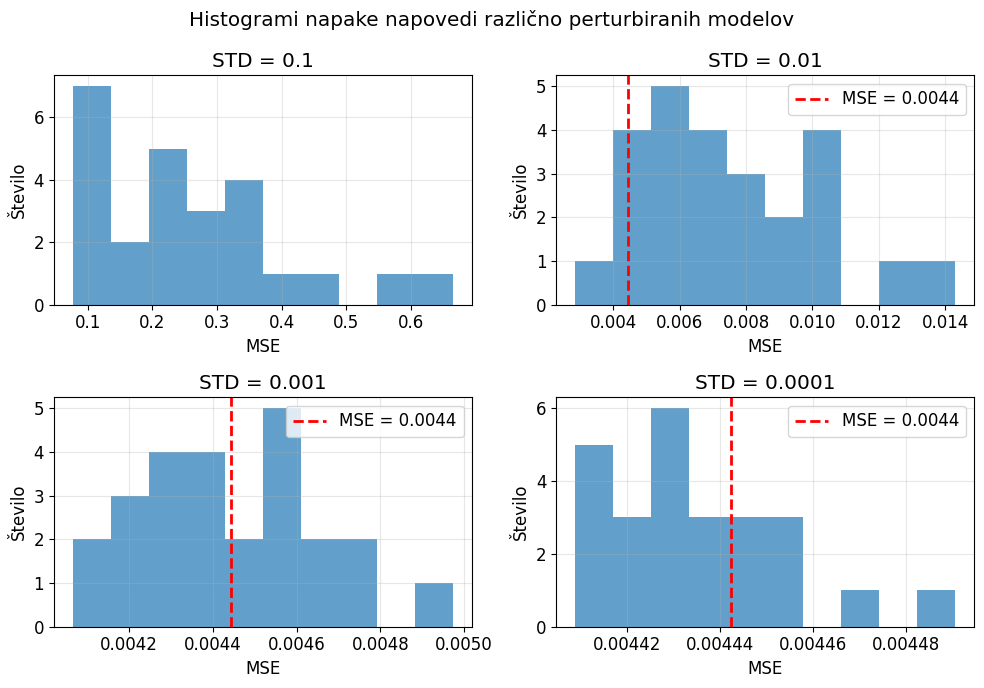

In [45]:
""" Histogram napovedi """

mse_base = base_model.evaluate(
    [X1_val, X1_val[:, -1:]],
    np.expand_dims(Y1_val, axis=1),
    verbose=0
)

stds = perturbation_stds
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
fig.suptitle("Histogrami napake napovedi različno perturbiranih modelov")
axs = axes.ravel()

for idx, std in enumerate(stds):
    ax = axs[idx]
    mse_values = results[std]

    ax.hist(mse_values, bins=10, alpha=0.7)
    ax.set_title(f"STD = {std}")
    ax.set_xlabel("MSE")
    ax.set_ylabel("Število")
    ax.grid(alpha=0.3)

    # --- DODAMO LE V ZADNJI HISTOGRAM ---
    if idx > len(stds) - 4:
        ax.axvline(
            mse_base,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"MSE = {mse_base:.4f}"
        )
        ax.legend()

plt.tight_layout()
plt.show()

In [43]:
import pickle

# Najboljši model za STD=0.01
best_std = 0.01
best_weights = best_models[best_std]['weights']

# Shranimo uteži z pickle
with open(f"best_model_weights_std_{best_std}.pkl", "wb") as f:
    pickle.dump(best_weights, f)

print("Uteži shranjene!")


Uteži shranjene!
